# 酒店评论 NLP 文本预处理

## Goal

使用 NLTK 和 pandas 对 `tripadvisor_hotel_reviews.csv` 进行一套清晰、可重复运行的文本预处理。

处理顺序：

1. 转换为小写
2. 删除英文停用词，但保留 `not`
3. 将 `*` 替换为 `start`
4. 删除所有标点符号
5. Tokenization 分词
6. Stemming 词干提取
7. Lemmatization 词形还原
8. N-gram 处理

## Setup / Imports

所有依赖统一放在顶部，便于检查环境和后续维护。

In [1]:
# Python 标准库：处理路径、正则表达式和标点符号。
from pathlib import Path
import re
import string
import unicodedata

# 第三方库：pandas 负责统计，Matplotlib 负责绘图，NLTK 负责自然语言处理。
import matplotlib.pyplot as plt
import pandas as pd
from nltk import ngrams, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

### Parameters

把容易调整的参数集中管理。以后更换数据文件、文本列或 N-gram 大小时，只需修改这里。

In [ ]:
# CSV 与 Notebook 位于同一目录，因此使用相对路径即可。
DATA_PATH = Path("tripadvisor_hotel_reviews.csv")

# 数据集中存放评论和评分的列名。
TEXT_COLUMN = "Review"
RATING_COLUMN = "Rating"

# N=2 表示生成 Bigram；改为 3 即可生成 Trigram。
NGRAM_N = 2

# 控制展示的样例数量，避免 Notebook 输出过长。
PREVIEW_ROWS = 3

# 统计和图表展示频次最高的 15 个 Bigram。
TOP_N_BIGRAMS = 15

## Data

### 1. 读取并检查数据

读取 CSV 后立即检查必需列，尽早发现文件或列名错误。原始 CSV 不会被修改。

In [3]:
# 读取酒店评论数据。
hotel_reviews = pd.read_csv(DATA_PATH)

# 检查后续代码需要的两列是否都存在。
required_columns = {TEXT_COLUMN, RATING_COLUMN}
missing_columns = required_columns - set(hotel_reviews.columns)

if missing_columns:
    raise ValueError(f"CSV 缺少必需列：{sorted(missing_columns)}")

# 显示数据规模、列名和少量样例。
print(f"数据行数：{len(hotel_reviews)}")
print(f"列名：{hotel_reviews.columns.tolist()}")
hotel_reviews.head(PREVIEW_ROWS)

数据行数：109
列名：['Review', 'Rating']


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3


## Text Cleaning

先保留原评论副本，后续用它做前后对比和完整性检查。

In [4]:
# astype('string') 统一 pandas 字符串类型；fillna('') 处理可能的空评论。
review_before = hotel_reviews[TEXT_COLUMN].astype("string").fillna("")

# 后续所有清洗都只修改 DataFrame 中的 Review 列，不会覆盖磁盘上的 CSV。
hotel_reviews[TEXT_COLUMN] = review_before.copy()

### 2. 转换为小写

统一英文大小写，避免 `Hotel` 和 `hotel` 被当作两个不同的词。

In [5]:
# pandas 的 str.lower() 会逐行转换字符串中的英文大写字母。
hotel_reviews[TEXT_COLUMN] = hotel_reviews[TEXT_COLUMN].str.lower()

### 3. 删除英文停用词，并保留 not

使用 NLTK 英文停用词表。`not` 表示否定，对情感分析很重要，因此从停用词表中移除。

In [6]:
# stopwords.words('english') 返回一个普通列表，复制后可以安全修改。
en_stopwords = stopwords.words("english")

# 明确保留 not：后续删除停用词时不会删除它。
en_stopwords.remove("not")

# 构建一次正则表达式，后续 109 条评论可以重复使用。
# (?<![a-z]) 和 (?![a-z]) 确保只匹配完整英文单词，而不是单词的一部分。
stopword_pattern = re.compile(
    r"(?<![a-z])(?:"
    + "|".join(re.escape(word) for word in sorted(en_stopwords, key=len, reverse=True))
    + r")(?![a-z])"
)

def remove_stopwords(text):
    """删除一条评论中的 NLTK 英文停用词，并整理多余空格。"""
    text_without_stopwords = stopword_pattern.sub(" ", text)
    return " ".join(text_without_stopwords.split())

# apply() 会把清洗函数应用到 Review 列的每一条评论。
hotel_reviews[TEXT_COLUMN] = hotel_reviews[TEXT_COLUMN].apply(remove_stopwords)

print(f"参与删除的英文停用词数量：{len(en_stopwords)}")
print(f"not 是否会被删除：{'not' in en_stopwords}")

参与删除的英文停用词数量：197
not 是否会被删除：False


### 4. 将星号替换为 start

必须在删除标点前处理 `*`，否则星号会直接消失。

In [7]:
# 记录替换前的星号数，用于最后验证是否全部完成替换。
star_count_before = int(hotel_reviews[TEXT_COLUMN].str.count(r"\*").sum())

# 记录原本就存在的 start 数量，避免把旧的 start 误算为星号替换结果。
start_count_before = int(
    hotel_reviews[TEXT_COLUMN]
    .str.split()
    .apply(lambda words: words.count("start"))
    .sum()
)

def replace_stars(text):
    """把一条评论中的每个星号替换成独立单词 start。"""
    replaced_text = text.replace("*", " start ")
    return " ".join(replaced_text.split())

hotel_reviews[TEXT_COLUMN] = hotel_reviews[TEXT_COLUMN].apply(replace_stars)

### 5. 删除所有标点符号

同时识别 Python 的英文标点表和 Unicode 标点。标点用空格替换，避免两侧单词粘连。

In [8]:
def is_punctuation(character):
    """判断字符是否属于英文标点或 Unicode 标点。"""
    is_ascii_punctuation = character in string.punctuation
    is_unicode_punctuation = unicodedata.category(character).startswith("P")
    return is_ascii_punctuation or is_unicode_punctuation

def remove_punctuation(text):
    """把标点替换为空格，并把连续空格整理为单个空格。"""
    characters = (" " if is_punctuation(char) else char for char in text)
    text_without_punctuation = "".join(characters)
    return " ".join(text_without_punctuation.split())

hotel_reviews[TEXT_COLUMN] = hotel_reviews[TEXT_COLUMN].apply(remove_punctuation)

### 6. 查看文本清洗前后对比

仅显示每条评论的前 160 个字符，保证输出容易阅读。

In [9]:
# 使用新的 DataFrame 展示对比，不修改 hotel_reviews 中的实际数据。
cleaning_comparison = pd.DataFrame({
    "处理前": review_before.str.slice(0, 160),
    "处理后": hotel_reviews[TEXT_COLUMN].str.slice(0, 160),
})

cleaning_comparison.head(PREVIEW_ROWS)

,处理前,处理后
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice rooms not 4 start experience hotel monaco...


### 7. 文本清洗检查

集中验证行数、大小写、停用词、`not`、星号替换和标点清理结果。

In [10]:
# 检查处理后的文本是否仍包含大写英文字母。
contains_uppercase = hotel_reviews[TEXT_COLUMN].str.contains(
    r"[A-Z]", regex=True, na=False
).any()

# 使用同一个判断函数检查是否仍有标点符号。
contains_punctuation = hotel_reviews[TEXT_COLUMN].apply(
    lambda text: any(is_punctuation(char) for char in text)
).any()

# 重新提取英文单词，与实际删除使用的停用词表做交集。
remaining_words = set(
    re.findall(r"[a-z]+", " ".join(hotel_reviews[TEXT_COLUMN]))
)
remaining_stopwords = remaining_words & set(en_stopwords)

# 比较处理前后的 not 数量，确认否定词没有被误删。
not_count_before = int(review_before.str.lower().str.count(r"\bnot\b").sum())
not_count_after = int(hotel_reviews[TEXT_COLUMN].str.count(r"\bnot\b").sum())

# 最终 start 数量减去原有数量，才是由星号替换得到的数量。
start_count_after = int(
    hotel_reviews[TEXT_COLUMN]
    .str.split()
    .apply(lambda words: words.count("start"))
    .sum()
)
star_replacement_count = start_count_after - start_count_before

assert len(hotel_reviews) == len(review_before), "处理前后行数不一致"
assert not contains_uppercase, "处理后的评论中仍包含大写字母"
assert not contains_punctuation, "处理后的评论中仍包含标点符号"
assert not remaining_stopwords, "处理后的评论中仍包含停用词"
assert not_count_after == not_count_before, "not 没有被完整保留"
assert star_replacement_count == star_count_before, "星号没有全部替换为 start"

print(f"✅ 文本清洗完成：{len(hotel_reviews)} 条评论")
print(f"✅ 保留 not：{not_count_after} 个")
print(f"✅ 星号替换为 start：{star_replacement_count} 个")
print("✅ 大写字母、停用词和标点检查通过")

✅ 文本清洗完成：109 条评论
✅ 保留 not：123 个
✅ 星号替换为 start：2 个
✅ 大写字母、停用词和标点检查通过


## NLTK Processing

以下四步都基于清洗后的 `Review`，并分别保存到新列，便于横向比较。

### 8. Tokenization 分词

把一整条评论拆分成 Token 列表，后续算法将以这些 Token 为输入。

In [11]:
def tokenize_review(text):
    """使用 NLTK 将一条清洗后的评论拆分为 Token 列表。"""
    return word_tokenize(text)

hotel_reviews["Tokens"] = hotel_reviews[TEXT_COLUMN].apply(tokenize_review)

print("第一条评论的前 20 个 Token：")
hotel_reviews.loc[0, "Tokens"][:20]

第一条评论的前 20 个 Token：


['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'reviews',
 'valet',
 'parking',
 'check']

### 9. Stemming 词干提取

PorterStemmer 通过规则去除词尾。结果适合归并相似词，但不保证是完整英文单词。

In [12]:
# Stemmer 只需创建一次，随后重复处理每条评论。
stemmer = PorterStemmer()

def stem_tokens(tokens):
    """对 Token 列表中的每个单词进行词干提取。"""
    return [stemmer.stem(token) for token in tokens]

hotel_reviews["Stemmed"] = hotel_reviews["Tokens"].apply(stem_tokens)

print("第一条评论的前 20 个词干：")
hotel_reviews.loc[0, "Stemmed"][:20]

第一条评论的前 20 个词干：


['nice',
 'hotel',
 'expens',
 'park',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversari',
 'arriv',
 'late',
 'even',
 'took',
 'advic',
 'previou',
 'review',
 'valet',
 'park',
 'check']

### 10. Lemmatization 词形还原

WordNetLemmatizer 尝试得到词典中的基本形式。本入门示例使用默认名词词性。

In [13]:
# Lemmatizer 同样只创建一次。
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """对 Token 列表中的每个单词执行词形还原。"""
    return [lemmatizer.lemmatize(token) for token in tokens]

hotel_reviews["Lemmatized"] = hotel_reviews["Tokens"].apply(lemmatize_tokens)

print("第一条评论的前 20 个词形还原结果：")
hotel_reviews.loc[0, "Lemmatized"][:20]

第一条评论的前 20 个词形还原结果：


['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'review',
 'valet',
 'parking',
 'check']

### 11. N-gram 处理

将相邻 Token 组合起来。当前 `NGRAM_N = 2`，因此生成的是 Bigram。

In [14]:
def build_ngrams(tokens, n):
    """根据 n 把 Token 列表转换为 N-gram 元组列表。"""
    return list(ngrams(tokens, n))

hotel_reviews["Ngrams"] = hotel_reviews["Tokens"].apply(
    lambda tokens: build_ngrams(tokens, NGRAM_N)
)

print(f"第一条评论的前 10 个 {NGRAM_N}-gram：")
hotel_reviews.loc[0, "Ngrams"][:10]

第一条评论的前 10 个 2-gram：


[('nice', 'hotel'),
 ('hotel', 'expensive'),
 ('expensive', 'parking'),
 ('parking', 'got'),
 ('got', 'good'),
 ('good', 'deal'),
 ('deal', 'stay'),
 ('stay', 'hotel'),
 ('hotel', 'anniversary'),
 ('anniversary', 'arrived')]

### 12. 使用 pandas 统计 Bigram 频次

将每条评论的 Bigram 列表展开为单列，再统计每种二元组的出现次数、排名和占比。

In [15]:
# explode() 将每行中的 Bigram 列表展开：一个 Bigram 占一行。
all_bigrams = hotel_reviews["Ngrams"].explode().dropna()

# value_counts() 统计每个 Bigram 元组出现的次数，并自动按降序排列。
bigram_frequency = (
    all_bigrams
    .value_counts()
    .rename_axis("Bigram")
    .reset_index(name="Count")
)

# 将 ('nice', 'hotel') 转换为 'nice hotel'，便于表格和图表阅读。
bigram_frequency["Bigram Text"] = bigram_frequency["Bigram"].apply(
    lambda words: " ".join(words)
)

# 排名从 1 开始；Share (%) 表示该 Bigram 占全部 Bigram 的比例。
bigram_frequency.insert(0, "Rank", range(1, len(bigram_frequency) + 1))
bigram_frequency["Share (%)"] = (
    bigram_frequency["Count"] / len(all_bigrams) * 100
).round(2)

# 只展示 Top-N，完整统计仍保存在 bigram_frequency 中。
top_bigrams = bigram_frequency.head(TOP_N_BIGRAMS).copy()
top_bigrams[["Rank", "Bigram Text", "Count", "Share (%)"]]

,Rank,Bigram Text,Count,Share (%)
0,1,great location,25,0.26
1,2,space needle,24,0.25
2,3,hotel monaco,16,0.17
3,4,staff friendly,12,0.13
4,5,pike place,12,0.13
5,6,great hotel,12,0.13
6,7,walking distance,11,0.12
7,8,location great,10,0.11
8,9,staff helpful,9,0.10
9,10,place market,9,0.10


### 13. 可视化高频 Bigram

横向柱状图更适合显示较长的二元组标签；频次最高的 Bigram 排在最上方。

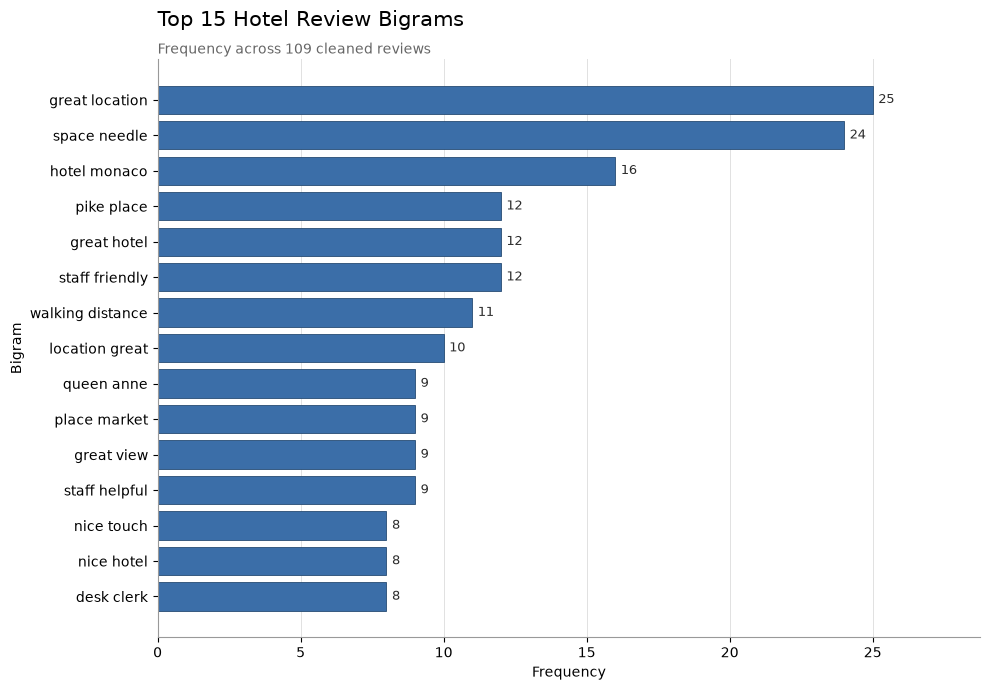

In [16]:
# barh() 从下往上绘制，因此先按 Count 升序排列，让最高频项显示在顶部。
plot_data = top_bigrams.sort_values("Count", ascending=True)

# 创建适合 Notebook 阅读的画布。
fig, ax = plt.subplots(figsize=(10, 7))

# 使用单一蓝色表达同一种指标，不添加重复图例。
bars = ax.barh(
    plot_data["Bigram Text"],
    plot_data["Count"],
    color="#3B6EA8",
    edgecolor="#264B73",
    linewidth=0.6,
)

# 在每根柱子末端直接显示次数，减少读者来回对照坐标轴。
ax.bar_label(bars, padding=4, fontsize=9, color="#2B2B2B")

# 标题说明图表内容，副标题补充数据范围和统计单位。
ax.set_title("Top 15 Hotel Review Bigrams", loc="left", fontsize=15, pad=24)
ax.text(
    0, 1.01,
    f"Frequency across {len(hotel_reviews)} cleaned reviews",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)
ax.set_xlabel("Frequency")
ax.set_ylabel("Bigram")

# 频次是绝对数量，因此横轴从 0 开始，并留出数值标签所需空间。
ax.set_xlim(0, plot_data["Count"].max() * 1.15)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)

# 隐藏不必要的边框，保留左侧和底部坐标锚点。
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#999999")
ax.spines["bottom"].set_color("#999999")

plt.tight_layout()
plt.show()

## Results

### 12. 查看完整流水线样例

每种列表只展示前几个元素，既能看出差异，也不会产生过长输出。

In [17]:
# 创建专门用于展示的小表，不改变完整处理结果。
pipeline_preview = pd.DataFrame({
    "Cleaned Review": hotel_reviews[TEXT_COLUMN].str.slice(0, 120),
    "Tokens": hotel_reviews["Tokens"].apply(lambda values: values[:12]),
    "Stemmed": hotel_reviews["Stemmed"].apply(lambda values: values[:12]),
    "Lemmatized": hotel_reviews["Lemmatized"].apply(lambda values: values[:12]),
    "Ngrams": hotel_reviews["Ngrams"].apply(lambda values: values[:6]),
})

pipeline_preview.head(PREVIEW_ROWS)

,Cleaned Review,Tokens,Stemmed,Lemmatized,Ngrams
0,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s...","[nice, hotel, expensive, parking, got, good, d...","[(nice, hotel), (hotel, expensive), (expensive..."
1,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi...","[ok, nothing, special, charge, diamond, member...","[(ok, nothing), (nothing, special), (special, ..."
2,nice rooms not 4 start experience hotel monaco...,"[nice, rooms, not, 4, start, experience, hotel...","[nice, room, not, 4, start, experi, hotel, mon...","[nice, room, not, 4, start, experience, hotel,...","[(nice, rooms), (rooms, not), (not, 4), (4, st..."


## Checks

验证每条评论都完成了四种 NLTK 处理，并检查各列表长度之间的关系。

In [18]:
# Token、词干和词形还原应该一一对应，因此长度必须相同。
token_lengths = hotel_reviews["Tokens"].str.len()
stem_lengths = hotel_reviews["Stemmed"].str.len()
lemma_lengths = hotel_reviews["Lemmatized"].str.len()

assert hotel_reviews["Tokens"].apply(lambda value: isinstance(value, list)).all()
assert (token_lengths == stem_lengths).all(), "Token 与词干数量不一致"
assert (token_lengths == lemma_lengths).all(), "Token 与词形还原数量不一致"

# 一条长度为 L 的 Token 列表，最多生成 max(L - N + 1, 0) 个 N-gram。
expected_ngram_lengths = token_lengths.apply(
    lambda length: max(length - NGRAM_N + 1, 0)
)
actual_ngram_lengths = hotel_reviews["Ngrams"].str.len()
assert (expected_ngram_lengths == actual_ngram_lengths).all(), "N-gram 数量不正确"

print(f"✅ {len(hotel_reviews)} 条评论已完成 Tokenization")
print("✅ Stemming、Lemmatization 和 N-gram 检查通过")

✅ 109 条评论已完成 Tokenization
✅ Stemming、Lemmatization 和 N-gram 检查通过


## Next Steps

目前已经得到结构清晰的文本处理结果。后续可以基于 `Tokens`、`Lemmatized` 或 `Ngrams` 进行词频统计、情感分析或文本分类。